In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pymoo.indicators.hv import Hypervolume
import score.envs as envs
import itertools

2024-10-01 10:53:10.216906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-01 10:53:10.235197: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-01 10:53:10.240520: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-01 10:53:10.252921: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-01 10:53:11.280455: W tensorflow/compiler/tf2

In [2]:
# env_id = "SCORE-MO-CEBAF-8D-VEC-TF"
env_id = "SCORE-MO-CEBAF-N-VEC-TF-v0"
env = envs.make(env_id)
ref = [env.linac.max_allowed_heat, env.linac.max_allowed_trip]
if "-8D-" in env_id:
    ideal = [20.9, 0.015]
    mobo_nsteps = 140
elif "-N-" in env_id:
    ideal = [2380.0, 1.0]
    mobo_nsteps = 1000
energy_bound = [env.min_energy, env.max_energy]

Attempting to load score.envs with mo_cebaf_env
####################################
Using action mode:  direct
####################################
Env Name:  north
Cavity Ids:  ['1L02-1' '1L02-2' '1L02-3' '1L02-4' '1L02-5' '1L02-6' '1L02-7' '1L02-8'
 '1L03-1' '1L03-2' '1L03-3' '1L03-4' '1L03-5' '1L03-6' '1L03-7' '1L03-8'
 '1L04-1' '1L04-2' '1L04-3' '1L04-4' '1L04-5' '1L04-6' '1L04-7' '1L04-8'
 '1L05-1' '1L05-2' '1L05-3' '1L05-4' '1L05-5' '1L05-6' '1L05-7' '1L05-8'
 '1L06-1' '1L06-2' '1L06-3' '1L06-4' '1L06-5' '1L06-6' '1L06-7' '1L06-8'
 '1L07-1' '1L07-2' '1L07-3' '1L07-4' '1L07-5' '1L07-6' '1L07-7' '1L07-8'
 '1L08-1' '1L08-2' '1L08-3' '1L08-4' '1L08-5' '1L08-6' '1L08-7' '1L08-8'
 '1L09-1' '1L09-2' '1L09-3' '1L09-4' '1L09-5' '1L09-6' '1L09-7' '1L09-8'
 '1L10-1' '1L10-2' '1L10-3' '1L10-4' '1L10-5' '1L10-6' '1L10-7' '1L10-8'
 '1L11-1' '1L11-2' '1L11-3' '1L11-4' '1L11-5' '1L11-6' '1L11-7' '1L11-8'
 '1L12-1' '1L12-2' '1L12-3' '1L12-4' '1L12-5' '1L12-6' '1L12-7' '1L12-8'
 '1L13-1' '1L13-2'

2024-10-01 10:53:14.027160: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13762 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:48:00.0, compute capability: 7.5
2024-10-01 10:53:14.029235: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13762 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:49:00.0, compute capability: 7.5
2024-10-01 10:53:14.031020: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 13762 MB memory:  -> device: 2, name: Tesla T4, pci bus id: 0000:4c:00.0, compute capability: 7.5
2024-10-01 10:53:14.032907: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 13762 MB memory:  -> device: 3, name: Tesla T4, pci bus id: 0000:4d:00.0, compute capability: 7.5


Using min, max energy boundaries as:  tf.Tensor(324.3, shape=(), dtype=float32) tf.Tensor(1148.1849, shape=(), dtype=float32)
Min and Max heat load:  tf.Tensor(269.85425, shape=(), dtype=float32) tf.Tensor(4904.527, shape=(), dtype=float32)
Min and Max trip rates:  tf.Tensor(0.07360049, shape=(), dtype=float32) tf.Tensor(24.809052, shape=(), dtype=float32)
Target energy: 1050
Energy min/max: 1048/1052
Low rewards: [  -24.809052 -4904.527   ]
High rewards: [-7.3600493e-02 -2.6985425e+02]
Initial state: tf.Tensor(
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [3]:
def calculate_hv(heat, trip, ref, ideal):
    metric = Hypervolume(ref_point= ref,
                         norm_ref_point=False,
                         zero_to_one=False,
                         ideal=ideal,
                         nadir=ref)
    max_vol = (ref[0] - ideal[0]) * (ref[1] - ideal[1])
    good_indices = np.where((heat <= ref[0]) & (trip <= ref[1]))[0]
    
    # If no points are below reference, return hypervolume as 0.
    if good_indices.shape[0] <= 0:
        return 0.
    heat, trip = heat[good_indices], trip[good_indices]
    results = np.stack([heat, trip], axis=1)
    
    return np.round(metric.do(results)*100/max_vol, 3)
    

In [4]:
def read_results(path, energy_min, energy_max, start, end, interval, ref, ideal):
    heat, trip, time, step_time = [], [], [], []
    hv_list = []
    for i in range(start, end, interval):
        filename = "inference_results_"+str(i).zfill(6)+".pkl"
        result_dict = np.load(os.path.join(path, filename), allow_pickle=True)
        h = np.array(result_dict["heat"])
        t = np.array(result_dict["trip"])
        if "MOBO" in path:
            energy = np.array(result_dict["energy"])
            good_indices = np.where((energy <= energy_max) & (energy >= energy_min))[0]
            h = h[good_indices]
            t = t[good_indices]
        heat.append(h)
        trip.append(t)
        step_time.append(result_dict["step_time"])
        time.append(result_dict["t_elapsed"])
        hv_list.append(calculate_hv(h, t, ref, ideal))
    return heat, trip, np.array(time), np.array(step_time), hv_list

In [5]:
if "-8D-" in env_id:
    mobo_path = "../results/MOO_paper_study_v2/MOBO/"
    moga_path = "../results/MOO_paper_study_v2/MOGA/"
    ddrl_path = "../results/MOO_paper_study_v2/DDRL/"
    motd3_path = None
else:
    mobo_path = "../results/MOO_paper_study_v2/MOBO_North/"
    moga_path = "../results/MOO_paper_study_v2/MOGA_North/"
    ddrl_path = "../results/MOO_paper_study_v2/DDRL_North/"
    motd3_path = None

In [6]:
path_list = [moga_path, ddrl_path, mobo_path, motd3_path]
label_list = ["MOGA", "DDRL", "MOBO", "MOTD3"]
colors = ["#FFAA00", "#00B000", "#E9002D", "black"]

In [7]:
mobo_heat_list, mobo_trip_list, mobo_time_list, mobo_hv_list = [], [], [], [] 
for i in range(1, 17):
    full_path = os.path.join(mobo_path, "trial_"+str(i))
    heat, trip, time, step_time, hv = read_results(full_path, energy_bound[0], energy_bound[1], 0, mobo_nsteps, 1, ref, ideal)
    mobo_heat_list.append(heat)
    mobo_trip_list.append(trip)
    mobo_time_list.append(time)
    mobo_hv_list.append(hv)

In [8]:
# padded = np.array(list(zip(*itertools.zip_longest(*x, fillvalue=0))))
# max_length = max([len(x) for x in mobo_heat_list])
# print(max_length)
# mobo_heat_list_padded = np.zeros((17, max_length, 8))
# mobo_trip_list_padded = np.zeros((17, max_length, 8))
# mobo_time
# mobo_heat_list = list(zip(*itertools.zip_longest(*mobo_heat_list, fillvalue=np.zeros(8))))
# mobo_trip_list = list(zip(*itertools.zip_longest(*mobo_trip_list, fillvalue=np.zeros(8))))
# mobo_time_list = list(zip(*itertools.zip_longest(*mobo_time_list, fillvalue=np.zeros(8))))
# mobo_hv_list = list(zip(*itertools.zip_longest(*mobo_hv_list, fillvalue=np.zeros(8))))

In [9]:
# mobo_hv_padded = np.array(list(zip(*itertools.zip_longest(*mobo_hv_list, fillvalue=0))))
# mobo_time_padded = np.array(list(zip(*itertools.zip_longest(*mobo_time_list, fillvalue=0))))

In [10]:
ddrl_heat_list, ddrl_trip_list, ddrl_time_list, ddrl_hv_list = [], [], [], [] 
for i in range(1, 16):
    full_path = os.path.join(ddrl_path, "trial_"+str(i))
    heat, trip, time, step_time, hv = read_results(full_path, energy_bound[0], energy_bound[1], 100, 50000, 100, ref, ideal)
    ddrl_heat_list.append(heat)
    ddrl_trip_list.append(trip)
    ddrl_time_list.append(time)
    ddrl_hv_list.append(hv)

In [11]:
moga_heat_list, moga_trip_list, moga_time_list, moga_hv_list = [], [], [], [] 
for i in range(1, 16):
    full_path = os.path.join(moga_path, "trial_"+str(i))
    heat, trip, time, step_time, hv = read_results(full_path, energy_bound[0], energy_bound[1], 100, 50000, 100, ref, ideal)
    moga_heat_list.append(heat)
    moga_trip_list.append(trip)
    moga_time_list.append(time)
    moga_hv_list.append(hv)

In [12]:
def get_hypervolume_comparison(hv_list, time_list, label_list, colors, x_axis="time"):
    for i in range(len(hv_list)):
        print(label_list[i], " Max HV: ", np.max(hv_list[i]))
        hv_mean = np.mean(hv_list[i], axis=0)
        hv_std = np.std(hv_list[i], axis=0)
        time_mean = np.mean(time_list[i], axis=0) / 60.
        time_std = np.std(time_list[i], axis=0) / 60.

        if x_axis == "time":
            x = time_mean
            xerr = time_std
            xlabel = "Time (min)"
        else:
            x = np.arange(len(time_mean))
            if "MOBO" not in label_list[i]:
                x = x*100
            xerr = None
            xlabel = "Steps"
        plt.errorbar(x, hv_mean, yerr=hv_std, xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=5, elinewidth=2, alpha=0.65)

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Hypervolume (Normalized %)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

# get_hypervolume_comparison([mobo_hv_list, moga_hv_list, ddrl_hv_list], [mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=["orange", "blue", "red"])
# get_hypervolume_comparison([mobo_hv_list, moga_hv_list, ddrl_hv_list], [mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=["orange", "blue", "red"], x_axis="step")

In [13]:
# get_hypervolume_comparison([ddrl_hv_list], [ddrl_time_list], ["DDRL"], colors=["orange", "blue", "red"])
# get_hypervolume_comparison([ddrl_hv_list], [ddrl_time_list], ["DDRL"], colors=["orange", "blue", "red"], x_axis="step")

MOBO  Max HV:  0.0
MOGA  Max HV:  64.411
DDRL  Max HV:  64.236


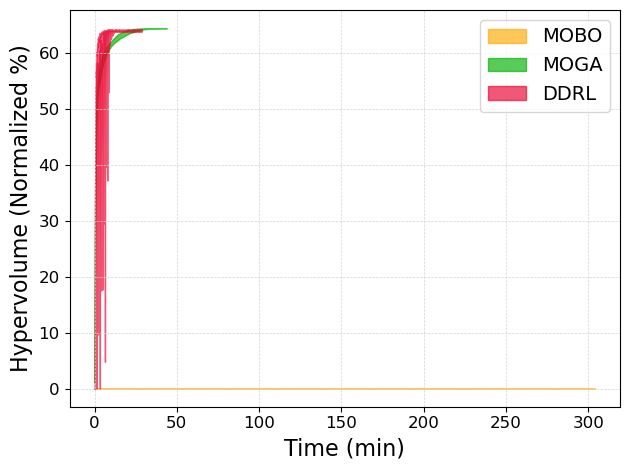

MOBO  Max HV:  0.0
MOGA  Max HV:  64.411
DDRL  Max HV:  64.236


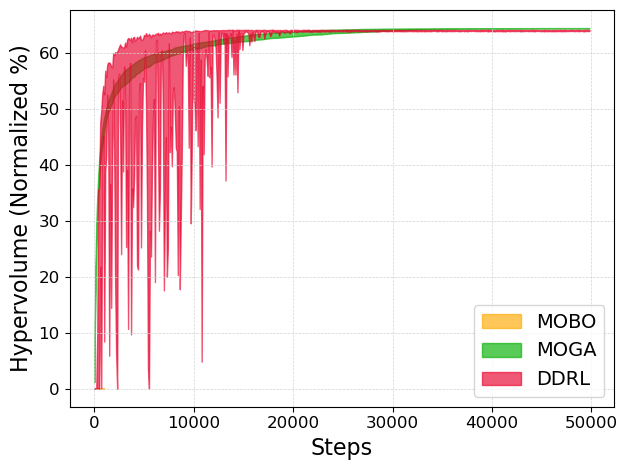

In [14]:
colors = ["#FFAA00", "#00B000", "#E9002D"]
def get_hypervolume_comparison_v2(hv_list, time_list, label_list, colors, x_axis="time", upper_q=0.75, lower_q=0.25, plot_type="area", xlim=None, ylim=None):
    for i in range(len(hv_list)):
        print(label_list[i], " Max HV: ", np.max(hv_list[i]))
        # hv_mean = np.mean(hv_list[i], axis=0)
        # hv_std = np.std(hv_list[i], axis=0)
        # time_mean = np.mean(time_list[i], axis=0) / 60.
        # time_std = np.std(time_list[i], axis=0) / 60.
        hv_median = np.median(hv_list[i], axis=0)
        hv_upper = np.quantile(hv_list[i], q=upper_q, axis=0) - hv_median
        hv_lower = hv_median - np.quantile(hv_list[i], q=lower_q, axis=0)
        time = np.array(time_list[i]) / 60.
        time_median = np.median(time, axis=0)
        time_upper = np.quantile(time, q=upper_q, axis=0) - time_median
        time_lower = time_median - np.quantile(time, q=lower_q, axis=0)

        if x_axis == "time":
            x = time_median
            xerr = np.vstack([time_lower, time_upper])
            xlabel = "Time (min)"
        else:
            x = np.arange(len(time_median))
            if "MOBO" not in label_list[i]:
                x = x*100
            xerr = None
            xlabel = "Steps"
        if plot_type == "area":
            plt.fill_between(x, y1=hv_median-hv_lower, y2=hv_median+hv_upper, label=label_list[i], color=colors[i], alpha=0.65)
            # plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)
        else:
            plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Hypervolume (Normalized %)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    # plt.xscale("log")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.tight_layout()
    plt.show()

one_sigma_bound = [0.186, 0.814]
two_sigma_bound = [0.023, 0.977]
get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list], [mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=colors, upper_q=one_sigma_bound[1], lower_q=one_sigma_bound[0], xlim=None, ylim=None)
get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list], [mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=colors, x_axis="step", upper_q=one_sigma_bound[1], lower_q=one_sigma_bound[0], xlim=None, ylim=None)

MOBO  Max HV:  0.0
(16, 1000)
MOGA  Max HV:  64.411
(15, 499)
DDRL  Max HV:  64.236
(15, 499)


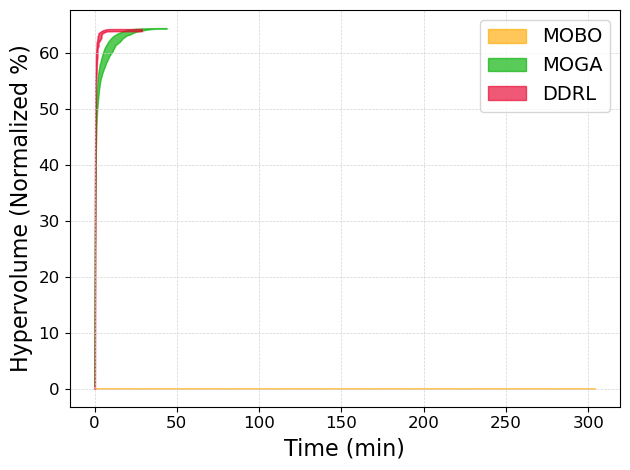

MOBO  Max HV:  0.0
(16, 1000)
MOGA  Max HV:  64.411
(15, 499)
DDRL  Max HV:  64.236
(15, 499)


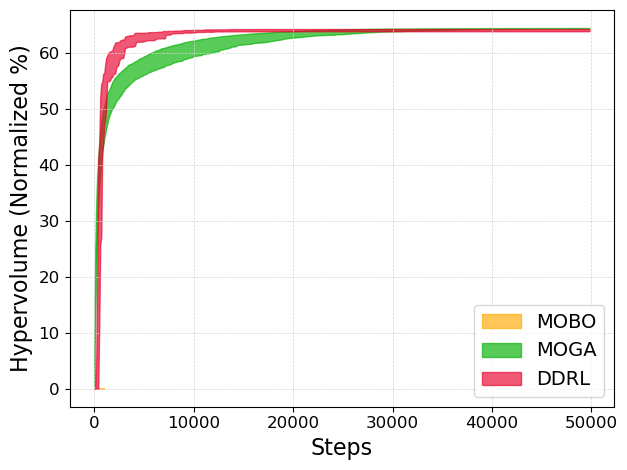

In [15]:
colors = ["#FFAA00", "#00B000", "#E9002D"]
def get_hypervolume_comparison_v3(hv_list, time_list, label_list, colors, x_axis="time", upper_q=0.75, lower_q=0.25, plot_type="area", xlim=None, ylim=None):
    for i in range(len(hv_list)):
        print(label_list[i], " Max HV: ", np.max(hv_list[i]))
        # hv_mean = np.mean(hv_list[i], axis=0)
        # hv_std = np.std(hv_list[i], axis=0)
        # time_mean = np.mean(time_list[i], axis=0) / 60.
        # time_std = np.std(time_list[i], axis=0) / 60.
        hv_cummax_list = np.array([np.maximum.accumulate(X) for X in hv_list[i]])
        print(hv_cummax_list.shape)
        hv_median = np.median(hv_cummax_list, axis=0)
        hv_upper = np.quantile(hv_cummax_list, q=upper_q, axis=0) - hv_median
        hv_lower = hv_median - np.quantile(hv_cummax_list, q=lower_q, axis=0)
        time = np.array(time_list[i]) / 60.
        time_median = np.median(time, axis=0)
        time_upper = np.quantile(time, q=upper_q, axis=0) - time_median
        time_lower = time_median - np.quantile(time, q=lower_q, axis=0)

        if x_axis == "time":
            x = time_median
            xerr = np.vstack([time_lower, time_upper])
            xlabel = "Time (min)"
        else:
            x = np.arange(len(time_median))
            if "MOBO" not in label_list[i]:
                x = x*100
            xerr = None
            xlabel = "Steps"
        if plot_type == "area":
            plt.fill_between(x, y1=hv_median-hv_lower, y2=hv_median+hv_upper, label=label_list[i], color=colors[i], alpha=0.65)
            # plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)
        else:
            plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Hypervolume (Normalized %)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    # plt.xscale("log")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.tight_layout()
    plt.show()

one_sigma_bound = [0.186, 0.814]
two_sigma_bound = [0.023, 0.977]
get_hypervolume_comparison_v3([mobo_hv_list, moga_hv_list, ddrl_hv_list], [mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
get_hypervolume_comparison_v3([mobo_hv_list, moga_hv_list, ddrl_hv_list], [mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO", "MOGA", "DDRL"], colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)

In [16]:
from jlab_opt_control.utils.losses import find_pareto_front

(0, 2)
(0,)


Text(0, 0.5, 'Trip Rate [per hour]')

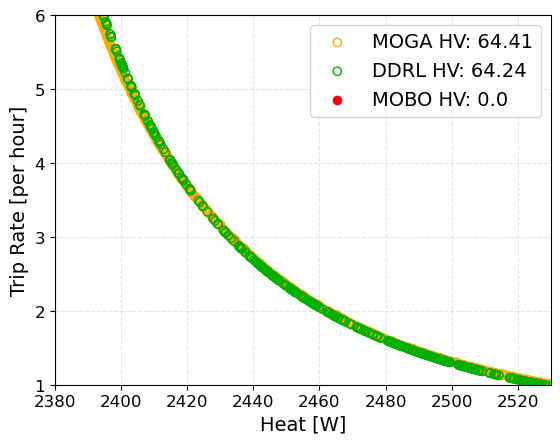

In [17]:
heat_global = [moga_heat_list, ddrl_heat_list, mobo_heat_list]
trip_global = [moga_trip_list, ddrl_trip_list, mobo_trip_list]
hv_global = [moga_hv_list, ddrl_hv_list, mobo_hv_list]
labels_global = ["MOGA", "DDRL", "MOBO"]
colors = ["#FFAA00", "#00B000", "#E9002D"]
t = [1.0, 1.0, 1.0]
for i in range(len(heat_global)):
    # heat_arr = []
    # trip_arr = []
    # for j in range(len(heat_global)):
    #     heat_arr.append(heat_global[i][j][-1])
    #     trip_arr.append(trip_global[i][j][-1])
    # mean_heat = np.mean(heat_arr, axis=0)
    # std_heat = np.mean(trip_arr, axis=0)
    # print(heat_global[i][-1][-1], trip_global[i][-1][-1])
    # break
    best_pareto_indices = np.where(hv_global[i] == np.max(hv_global[i]))
    max_hv = np.round(np.max(hv_global[i]), 2)
    heat = heat_global[i][best_pareto_indices[0][0]][best_pareto_indices[1][0]]
    trip = trip_global[i][best_pareto_indices[0][0]][best_pareto_indices[1][0]]
    if "MOBO" in labels_global[i]:
        results = find_pareto_front(np.stack([heat, trip], axis=1))
        print(results.shape)
        heat, trip = results[:, 0], results[:, 1]
        print(heat.shape)
        facecolor="red"
    else:
        facecolor="none"
    plt.scatter(heat, trip, label=labels_global[i]+" HV: "+str(max_hv), edgecolor=colors[i], alpha=t[i], marker="o", facecolor=facecolor)#, facecolor="none")
plt.legend(fontsize=14)
plt.xlim([ideal[0], ref[0]])
plt.ylim([ideal[1], ref[1]])
plt.grid(color="gray", linestyle="--", alpha=0.2)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Heat [W]", fontsize=14)
plt.ylabel("Trip Rate [per hour]", fontsize=14)

[ 2.50453709e-02 -9.37483855e+00  8.82871188e+02]
Coefficient of determination:  0.9935016146818911


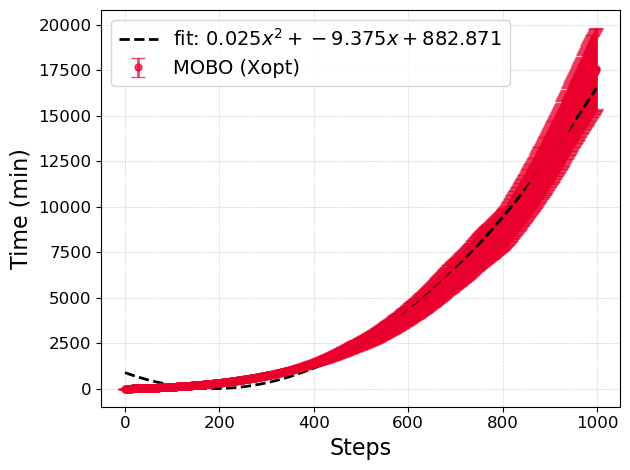

[-4.98221765e-09  3.47773703e-02  2.42805216e+00]
Coefficient of determination:  0.9999997406181929


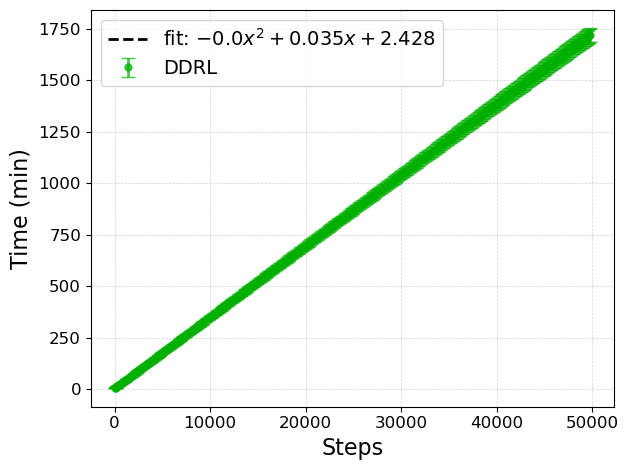

[-2.63996435e-09  5.27213081e-02  5.05682007e+00]
Coefficient of determination:  0.9999999335774811


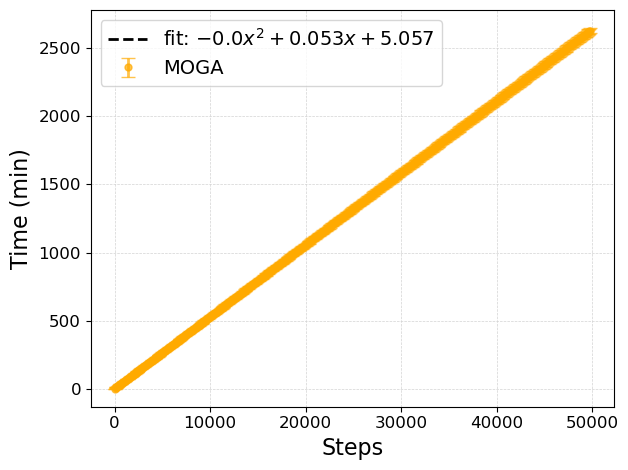

[ 2.50453709e-02 -9.37483855e+00  8.82871188e+02]
Coefficient of determination:  0.9935016146818911
[-2.63996435e-09  5.27213081e-02  5.05682007e+00]
Coefficient of determination:  0.9999999335774811
[-4.98221765e-09  3.47773703e-02  2.42805216e+00]
Coefficient of determination:  0.9999997406181929


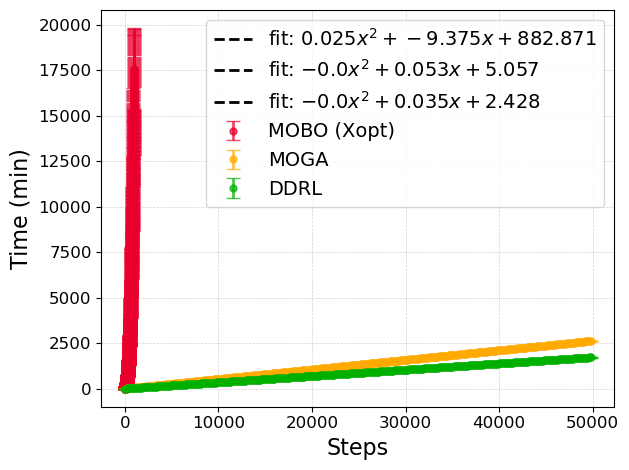

In [18]:
def get_time_evolution(time_list, label_list, colors):
    for i in range(len(time_list)):
        time_mean = np.mean(time_list[i], axis=0)
        time_std = np.std(time_list[i], axis=0)
        
        x = np.arange(len(time_mean))
        if "MOBO" not in label_list[i]:
            x = x * 100

        
        coeff = np.polyfit(x, time_mean, 2)
        print(coeff)
        p = np.poly1d(coeff)
        # fit values, and mean
        yhat = p(x)                         # or [p(z) for z in x]
        ybar = np.sum(time_mean)/len(time_mean)          # or sum(y)/len(y)
        ssreg = np.sum((yhat-ybar)**2)   # or sum([ (yihat - ybar)**2 for yihat in yhat])
        sstot = np.sum((time_mean - ybar)**2)    # or sum([ (yi - ybar)**2 for yi in y])
        r_square = ssreg / sstot
        print("Coefficient of determination: ", r_square)
        
        fit_x = np.arange(len(time_mean))
        fit_y = coeff[0]*fit_x**2 + coeff[1]*fit_x + coeff[2]
            
        plt.errorbar(x, y=time_mean, yerr=time_std, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=5, elinewidth=2, alpha=0.7)
        # if "MOBO" in label_list[i]:
        #     # plt.plot(x, 0.2*x+(x*0.045)**3, color="black", linestyle='--', label="fit: $0.2x + 0.025*x^3$", linewidth=2)
        #     plt.plot(fit_x, fit_y, color="black", linestyle='--', label="fit: $0.2x + 0.025*x^3$", linewidth=2)
        # if "MOGA" in label_list[i]:
        coeff = np.round(coeff, 3)
        label_str = "fit: $"+str(coeff[0])+"x^2 + "+str(coeff[1])+"x + "+str(coeff[2])+"$"
        plt.plot(fit_x, fit_y, color="black", linestyle='--', label=label_str, linewidth=2)
            
            
        
    plt.xlabel("Steps", fontsize=16)
    plt.ylabel("Time (min)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

# get_time_evolution([time_list, ddrl_time_list], ["MOBO (Xopt)", "DDRL"], ["orange", "pink"])
get_time_evolution([mobo_time_list], ["MOBO (Xopt)"], ["#E9002D"])
get_time_evolution([ddrl_time_list], ["DDRL"], ["#00B000"])
get_time_evolution([moga_time_list], ["MOGA"], ["#FFAA00"])
get_time_evolution([mobo_time_list, moga_time_list, ddrl_time_list], ["MOBO (Xopt)", "MOGA", "DDRL"], ["#E9002D", "#FFAA00", "#00B000"])